In [33]:
import os 
import glob
import pandas as pd 
import numpy as np
import librosa 
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt
import IPython.display as ipd
import fnmatch
import math

In [34]:
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch
from imblearn.over_sampling import SMOTE
from collections import Counter

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [36]:
base_path = r"C:\Users\Sandeep\Desktop\Projects\Datasets\Heartbeat_Sound"
print(os.listdir(base_path))

['artifact', 'extrahls', 'extrastole', 'murmur', 'normal', 'unlabel']


In [37]:
unlable_data = base_path + "/unlabel/" 

normal_data = base_path + "/normal/"
murmur_data = base_path + "/murmur/"
extrastole_data = base_path + "/extrastole/"
artifact_data = base_path + "/artifact/"
extrahls_data = base_path + "/extrahls/"

In [38]:
# All Training data
print("noraml files", len(os.listdir(normal_data)))
print("murmur files", len(os.listdir(murmur_data)))
print("extrastole files", len(os.listdir(extrastole_data)))
print("artifact files", len(os.listdir(artifact_data)))
print("extrahls files", len(os.listdir(extrahls_data)))

noraml files 351
murmur files 129
extrastole files 46
artifact files 40
extrahls files 19


In [39]:
# Test Data
print("test files", len(os.listdir(unlable_data)))

test files 247


([<matplotlib.patches.Wedge at 0x163ee208cd0>,
 [Text(-0.5098781582571872, 1.569243213696417, 'normal'),
  Text(-0.40776277782741904, -1.5988212898940481, 'murmur'),
  Text(1.0503837039080206, -1.2724755693389433, 'extrastole'),
  Text(1.5073501318262326, -0.6711151764663347, 'artifact'),
  Text(1.64141835395155, -0.16806483067847702, 'extrahls')],
 [Text(-0.2781153590493748, 0.8559508438344091, '60%'),
  Text(-0.22241606063313762, -0.8720843399422079, '22%'),
  Text(0.5729365657680111, -0.6940775832757872, '8%'),
  Text(0.8221909809961266, -0.3660628235270916, '7%'),
  Text(0.8953191021553907, -0.09167172582462382, '3%')])

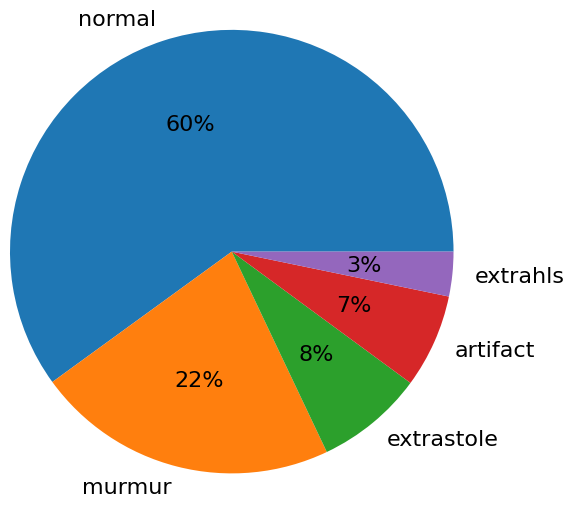

In [40]:
# Pie chart visualization
X = np.array([len(os.listdir(normal_data)), len(os.listdir(murmur_data)), len(os.listdir(extrastole_data)), len(os.listdir(artifact_data)), len(os.listdir(extrahls_data))])

labels = ["normal", "murmur", "extrastole", "artifact", "extrahls"]

plt.pie(X, labels = labels, radius = 1.5, textprops = {"fontsize": 16}, autopct = "%.0f%%")

In [41]:
# function for adding noise
def noise(data, x):
    noise = np.random.randn(len(data))
    data_noise = data + x * noise
    return data_noise

def shift(data, x):
    return np.roll(data, x)

def stretch(data, rate):
    return librosa.effects.time_stretch(y = data, rate = rate)

def pitch(data, rate, sr = 22050):
    return librosa.effects.pitch_shift(y = data, sr = sr, n_steps = rate)

In [42]:
# Map label text to integers (0, 1, 2)

Classes = ["artifact", "murmur", "normal"]
Nb_classes = len(Classes)

# Map int to text labels
label_to_int = {k:v for v, k in enumerate(Classes)}
print(label_to_int)
print("")
int_to_lable = {v:k for k, v in label_to_int.items()}
print(int_to_lable)

{'artifact': 0, 'murmur': 1, 'normal': 2}

{0: 'artifact', 1: 'murmur', 2: 'normal'}


In [43]:
def load_file_data(folder, file_names, duration = 10, sr = 22050):

    '''
    1) orignal audio to MFCC
    2) Slowed audio to MFCC
    3) sped up audio to MFCC

    '''
    input_length = sr * duration
    features = 52
    data = []

    for file_name in file_names:
        try:
            sound_file = folder + file_name
            X, sr = librosa.load(sound_file, sr = sr, duration = duration)
            dur = librosa.get_duration(y = X, sr = sr)

            # pad audio file to same duration
            if round(dur) < duration:
                print("Fixing Audio length",file_name)
                X = librosa.util.fix_length(data = X, size = input_length)

            # Orignal MFCC
            mfccs = np.mean(librosa.feature.mfcc(y = X, sr = sr, n_mfcc = features).T, axis = 0)
            data.append(mfccs.reshape([-1, 1]))

            # stretch 0.8
            stretch_1 = stretch(X, 0.8)
            mfcc_1 = np.mean(librosa.feature.mfcc(y = stretch_1, sr = sr, n_mfcc = features).T, axis = 0)
            data.append(mfcc_1.reshape([-1, 1]))

            # Stretch 1.2
            stretch_2 = stretch(X, 1.2)
            mfcc_2 = np.mean(librosa.feature.mfcc(y = stretch_2, sr = sr, n_mfcc = features).T, axis = 0)
            data.append(mfcc_2.reshape([-1, 1]))

        except Exception as e:
            print("Error in", file_name, "=>", e)

    return data

In [44]:
def load_all_categories(categories, sample_rate=22050, duration=10):
    """
    categories: list of dicts with keys:
        - 'folder': path to audio folder
        - 'prefix': filename prefix e.g. "murmur"
        - 'label' : integer label
    """
    all_sounds = []
    all_labels = []

    for cat in categories:
        files = fnmatch.filter(os.listdir(cat['folder']), f"{cat['prefix']}*.wav")
        sounds = load_file_data(folder=cat['folder'], file_names=files, duration=duration, sr=sample_rate)
        labels = [cat['label'] for _ in sounds]

        all_sounds.extend(sounds)
        all_labels.extend(labels)

        print(f"Loaded {len(sounds)} samples for '{cat['prefix']}'")

    print("Loading Done")
    return all_sounds, all_labels

In [45]:
categories = [
    {'folder': artifact_data,   'prefix': 'artifact',   'label': 0},
    {'folder': murmur_data,     'prefix': 'murmur',     'label': 1},
    {'folder': normal_data,     'prefix': 'normal',     'label': 2},
    {'folder': extrahls_data,   'prefix': 'extrahls',   'label': 2},
    {'folder': extrastole_data, 'prefix': 'extrastole', 'label': 2},
]

all_sounds, all_labels = load_all_categories(categories, sample_rate=22050, duration=10)

Fixing Audio length artifact__201012172012.wav
Fixing Audio length artifact__201105040918.wav
Fixing Audio length artifact__201105041959.wav
Fixing Audio length artifact__201105051017.wav
Fixing Audio length artifact__201105060108.wav
Fixing Audio length artifact__201105061143.wav
Fixing Audio length artifact__201105190800.wav
Fixing Audio length artifact__201105280851.wav
Fixing Audio length artifact__201106010559.wav
Fixing Audio length artifact__201106010602.wav
Fixing Audio length artifact__201106021541.wav
Fixing Audio length artifact__201106030612.wav
Fixing Audio length artifact__201106031558.wav
Fixing Audio length artifact__201106040722.wav
Fixing Audio length artifact__201106040933.wav
Fixing Audio length artifact__201106040947.wav
Fixing Audio length artifact__201106041452.wav
Fixing Audio length artifact__201106050353.wav
Fixing Audio length artifact__201106061233.wav
Fixing Audio length artifact__201106070537.wav
Fixing Audio length artifact__201106070949.wav
Fixing Audio 

In [46]:
def load_unlabeled_data(folder, prefixes, duration=10, sr=22050):
    """
    folder:   path to unlabeled audio folder
    prefixes: list of filename prefixes e.g. ["Aunlabelledtest", "Bunlabelledtest"]
    """
    all_sounds = []
    all_labels = []

    for prefix in prefixes:
        files = fnmatch.filter(os.listdir(folder), f"{prefix}*.wav")
        sounds = load_file_data(folder=folder, file_names=files, duration=duration, sr=sr)
        labels = [-1 for _ in sounds]

        all_sounds.extend(sounds)
        all_labels.extend(labels)

        print(f"Loaded {len(sounds)} unlabeled samples for '{prefix}'")

    print("Loading of Unlabeled data Done")
    return all_sounds, all_labels

In [47]:
unlabeled_sounds, unlabeled_labels = load_unlabeled_data(
    folder=unlable_data,
    prefixes=["Aunlabelledtest", "Bunlabelledtest"],
    duration=10
)

Fixing Audio length Aunlabelledtest__201012172010.wav
Fixing Audio length Aunlabelledtest__201101051105.wav
Fixing Audio length Aunlabelledtest__201101061552.wav
Fixing Audio length Aunlabelledtest__201101091156.wav
Fixing Audio length Aunlabelledtest__201101110659.wav
Fixing Audio length Aunlabelledtest__201101152256.wav
Fixing Audio length Aunlabelledtest__201101220549.wav
Fixing Audio length Aunlabelledtest__201101241434.wav
Fixing Audio length Aunlabelledtest__201102081033.wav
Fixing Audio length Aunlabelledtest__201102081045.wav
Fixing Audio length Aunlabelledtest__201102200848.wav
Fixing Audio length Aunlabelledtest__201103011036.wav
Fixing Audio length Aunlabelledtest__201103140236.wav
Fixing Audio length Aunlabelledtest__201103170122.wav
Fixing Audio length Aunlabelledtest__201103200518.wav
Fixing Audio length Aunlabelledtest__201103201314.wav
Fixing Audio length Aunlabelledtest__201103232251.wav
Fixing Audio length Aunlabelledtest__201103241336.wav
Fixing Audio length Aunlabel

In [48]:
def combine_data(labeled_sounds, labeled_labels, unlabeled_sounds, unlabeled_labels):
    x_data = np.array(labeled_sounds)
    y_data = np.array(labeled_labels)

    test_x = np.array(unlabeled_sounds)
    test_y = np.array(unlabeled_labels)

    print(f"Labeled samples:   {len(y_data)}")
    print(f"Unlabeled samples: {len(test_y)}")

    return x_data, y_data, test_x, test_y

In [49]:
x_data, y_data, test_x, test_y = combine_data(
    labeled_sounds=all_sounds,
    labeled_labels=all_labels,
    unlabeled_sounds=unlabeled_sounds,
    unlabeled_labels=unlabeled_labels
)

Labeled samples:   1755
Unlabeled samples: 741


In [50]:
def split_and_encode(x_data, y_data, test_y, classes, train_size=0.8, val_size=0.9, random_state=80085):
    """
    x_data:       feature array
    y_data:       label array
    test_y:       unlabeled test labels
    classes:      list of classes e.g. [0, 1, 2]
    train_size:   proportion for train split (default 0.8)
    val_size:     proportion of train set for validation (default 0.9)
    random_state: reproducibility seed
    """
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        x_data, y_data, train_size=train_size, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, train_size=val_size, random_state=random_state
    )

    # One hot encode using PyTorch
    num_classes = len(classes)

    def one_hot(labels, num_classes):
        labels = np.array(labels)
        
        # handle -1 unlabeled by temporarily replacing with 0
        mask = labels == -1
        labels_fixed = labels.copy()
        labels_fixed[mask] = 0
        
        t = torch.tensor(labels_fixed, dtype=torch.long)
        encoded = F.one_hot(t, num_classes=num_classes).numpy()
        
        # zero out the rows that were -1 (unlabeled)
        encoded[mask] = 0
        
        return encoded

    y_train = one_hot(y_train, num_classes)
    y_test  = one_hot(y_test,  num_classes)
    y_val   = one_hot(y_val,   num_classes)
    test_y  = one_hot(test_y,  num_classes)

    print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

    return X_train, X_val, X_test, y_train, y_val, y_test, test_y

In [51]:
X_train, X_val, X_test, y_train, y_val, y_test, test_y = split_and_encode(
    x_data=x_data,
    y_data=y_data,
    test_y=test_y,
    classes=Classes
)

X_train: (1263, 52, 1) | y_train: (1263, 3)
X_val:   (141, 52, 1)   | y_val:   (141, 3)
X_test:  (351, 52, 1)  | y_test:  (351, 3)


In [57]:
# SMOTE helper function
def apply_smote(X_train, y_train, random_state=42):
    """
    X_train: (samples, 52, 1)
    y_train: one-hot encoded (samples, num_classes)
    """
    # Flatten and convert one-hot to integers
    X_flat = X_train.reshape(len(X_train), -1)       # (samples, 52)
    y_flat = y_train.argmax(axis=1)                   # (samples,)

    print("Before SMOTE:", Counter(y_flat))

    sm = SMOTE(random_state=random_state)
    X_resampled, y_resampled = sm.fit_resample(X_flat, y_flat)

    print("After SMOTE: ", Counter(y_resampled))

    # Reshape back and re-encode to one-hot
    X_resampled = X_resampled.reshape(-1, 52, 1)
    y_resampled = F.one_hot(
        torch.tensor(y_resampled, dtype=torch.long),
        num_classes=y_train.shape[1]
    ).numpy()

    return X_resampled, y_resampled

In [58]:
class HeartMurmurLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, num_classes=3, dropout=0.5):
        super(HeartMurmurLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,  # 64 hidden units
            num_layers  = num_layers,   # 1 layer
            batch_first = True,
            dropout     = 0            # no dropout inside LSTM for single layer
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),  # 32 instead of 64
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.classifier(out)
        return out


# Init model
model = HeartMurmurLSTM(input_size=1, hidden_size=64, num_layers=1, num_classes=3, dropout=0.5)
print(model)

HeartMurmurLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
    (4): Softmax(dim=1)
  )
)


In [59]:
def create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32):
    """Convert numpy arrays to PyTorch DataLoaders"""

    def to_tensor(X, y):
        X_t = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32)
        return TensorDataset(X_t, y_t)

    train_loader = DataLoader(to_tensor(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(to_tensor(X_val,   y_val),   batch_size=batch_size)
    test_loader  = DataLoader(to_tensor(X_test,  y_test),  batch_size=batch_size)

    return train_loader, val_loader, test_loader


def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, class_weights = None, patience=15, weight_decay=1e-4):
    """
    model:        HeartMurmurLSTM instance
    train_loader: training DataLoader
    val_loader:   validation DataLoader
    epochs:       number of training epochs
    lr:           learning rate
    class_weights: optional tensor of class weights
    patience:      early stopping patience (epochs without improvement)
    """
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5, verbose=True
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    # ── Early stopping state ───────────────────────────────────
    best_val_loss  = float('inf')
    best_model     = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        # ── Training ──────────────────────────────────────────
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            preds = outputs.argmax(dim=1)
            labels = y_batch.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += len(labels)

        # ── Validation ────────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                labels = y_batch.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += len(labels)

        # ── Metrics ───────────────────────────────────────────
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        train_acc = train_correct / train_total * 100
        val_acc = val_correct / val_total * 100

        history["train_loss"].append(train_loss_avg)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss_avg)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss_avg)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.2f}% | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # ── Early stopping ────────────────────────────────────
        if val_loss_avg < best_val_loss:
            best_val_loss = val_loss_avg
            best_model    = model.state_dict().copy()
            epochs_no_improve = 0
            print(f"  ✓ Best model saved (val_loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\n Early stopping at epoch {epoch+1} — no improvement for {patience} epochs")
                break
    
    # ── Restore best model ────────────────────────────────────
    model.load_state_dict(best_model)
    print(f"\nTraining complete. Best Val Loss: {best_val_loss:.4f}")
    return model, history

In [88]:
# 1. Apply SMOTE first
#X_train_sm, y_train_sm = apply_smote(X_train, y_train)

# 2. Create dataloaders with SMOTE data
train_loader, val_loader, test_loader = create_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32
)

# 3. Init SIMPLE model (64 hidden, 1 layer)
model = HeartMurmurLSTM(input_size=1, hidden_size=64, num_layers=1, num_classes=3, dropout=0.5)

total = 120 + 387 + 1248
weights = torch.tensor([
    total / 120,    # artifact  = 14.6
    total / 387,    # murmur    = 4.5
    total / 1248,   # normal    = 1.4
], dtype=torch.float32)

# 4. Train WITH class weights
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    lr=0.001,        
    class_weights=weights,
    patience=15,
    weight_decay=0  
)

import os

# Save model
model_path = os.path.join("../", "model_files", "heart_murmur_model.pth")
os.makedirs(os.path.dirname(model_path), exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_size': 1,
        'hidden_size': 64,
        'num_layers': 1,
        'num_classes': 3,
        'dropout': 0.5
    }
}, model_path)

print(f"Model saved to {model_path}")

c:\Users\Sandeep\anaconda3\envs\heart\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch [01/100] Train Loss: 3.2225 | Train Acc: 13.54% | Val Loss: 3.3857 | Val Acc: 9.22% | LR: 0.001000
  ✓ Best model saved (val_loss: 3.3857)
Epoch [02/100] Train Loss: 3.1478 | Train Acc: 41.73% | Val Loss: 3.1475 | Val Acc: 61.70% | LR: 0.001000
  ✓ Best model saved (val_loss: 3.1475)
Epoch [03/100] Train Loss: 2.9150 | Train Acc: 59.14% | Val Loss: 2.8442 | Val Acc: 59.57% | LR: 0.001000
  ✓ Best model saved (val_loss: 2.8442)
Epoch [04/100] Train Loss: 2.8434 | Train Acc: 50.67% | Val Loss: 2.7611 | Val Acc: 73.05% | LR: 0.001000
  ✓ Best model saved (val_loss: 2.7611)
Epoch [05/100] Train Loss: 2.6710 | Train Acc: 57.96% | Val Loss: 3.1315 | Val Acc: 47.52% | LR: 0.001000
Epoch [06/100] Train Loss: 2.5516 | Train Acc: 61.60% | Val Loss: 2.7353 | Val Acc: 66.67% | LR: 0.001000
  ✓ Best model saved (val_loss: 2.7353)
Epoch [07/100] Train Loss: 2.5250 | Train Acc: 71.42% | Val Loss: 2.6815 | Val Acc: 73.76% | LR: 0.001000
  ✓ Best model saved (val_loss: 2.6815)
Epoch [08/100] Trai

In [89]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader, classes, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            preds   = outputs.argmax(dim=1).cpu().numpy()
            labels  = y_batch.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    # Classification report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels

Classification Report:
              precision    recall  f1-score   support

    artifact       0.88      0.91      0.89        32
      murmur       0.67      0.64      0.65        75
      normal       0.89      0.90      0.89       244

    accuracy                           0.84       351
   macro avg       0.81      0.81      0.81       351
weighted avg       0.84      0.84      0.84       351



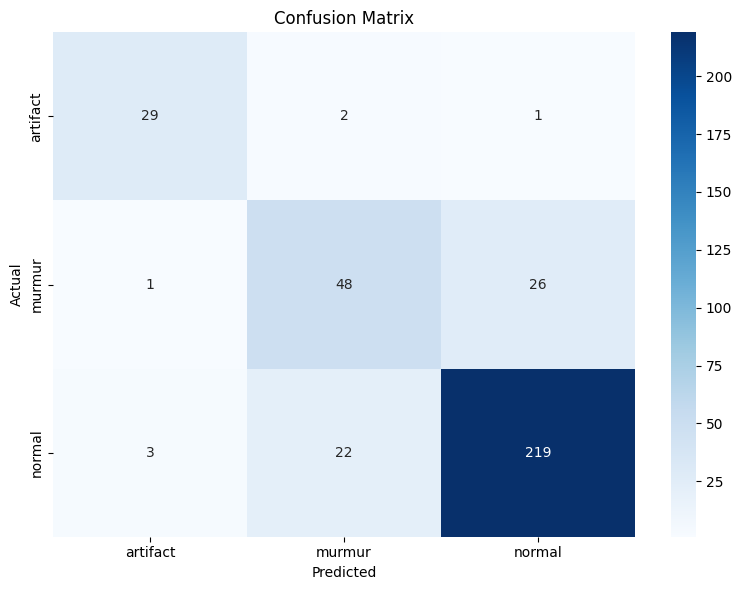

In [90]:
classes = ['artifact', 'murmur', 'normal']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_preds, all_labels = evaluate_model(
    model=model,
    test_loader=test_loader,
    classes=classes,
    device=device
)